## 0. Setup

In [3]:
import sys
import os

# Ensure the project root is on the path so `src` is importable
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.data_ingestion import load_raw_data
from src.preprocessing import run_preprocessing_pipeline
from src.feature_engineering import (
    get_feature_types,
    run_feature_engineering_pipeline,
)

print('All imports OK.')

All imports OK.


## 1. Data Ingestion

Load all eight CICIDS2017 CSV files from `Input/` and concatenate them into a single DataFrame.

In [4]:
INPUT_DIR = os.path.join(PROJECT_ROOT, 'Input')

df_raw = load_raw_data(INPUT_DIR)
print(f'Raw shape: {df_raw.shape}')
df_raw.head(3)

  Loading: /Users/anhoang/PycharmProjects/DAP391m/Project/Input/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  Loading: /Users/anhoang/PycharmProjects/DAP391m/Project/Input/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  Loading: /Users/anhoang/PycharmProjects/DAP391m/Project/Input/Friday-WorkingHours-Morning.pcap_ISCX.csv
  Loading: /Users/anhoang/PycharmProjects/DAP391m/Project/Input/Monday-WorkingHours.pcap_ISCX.csv
  Loading: /Users/anhoang/PycharmProjects/DAP391m/Project/Input/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  Loading: /Users/anhoang/PycharmProjects/DAP391m/Project/Input/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
  Loading: /Users/anhoang/PycharmProjects/DAP391m/Project/Input/Tuesday-WorkingHours.pcap_ISCX.csv
  Loading: /Users/anhoang/PycharmProjects/DAP391m/Project/Input/Wednesday-workingHours.pcap_ISCX.csv

  Loaded 8 file(s). Concatenating …
  ✓ Merged dataset shape: 2,830,743 rows × 79 columns

Raw shape: (2830743, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


## 2. Preprocessing

Run the full cleaning pipeline:
- Strip column names
- Remove duplicates
- Remove identity (all-same-values) columns
- Replace ±inf with NaN and drop NaN rows
- Rename `Label` → `Attack Type` and group attack subtypes

In [5]:
df_clean = run_preprocessing_pipeline(df_raw)

# Free raw DataFrame from memory
del df_raw

print(f'Clean shape: {df_clean.shape}')
df_clean['Attack Type'].value_counts()

  PREPROCESSING PIPELINE
  remove_duplicates: removed 308,381 duplicate rows (10.89%)
  remove_identity_columns: dropping 12 redundant column(s): ['Subflow Fwd Packets', 'Subflow Bwd Packets', 'SYN Flag Count', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate', 'CWE Flag Count', 'Fwd Header Length']
  handle_infinite_values: replaced 2,775 infinite value(s) with NaN.
  handle_missing_values (drop): removed 1,564 rows containing NaN (0.06%)
  standardise_label_column: removed 36 rows belonging to ['Infiltration', 'Miscellaneous'].

  Attack Type distribution after standardisation:
Attack Type
BENIGN                        2095057
DoS                            193745
DDoS                           128014
PortScan                        90694
Brute Force                      9150
Bot                              1948
Web Attack � Brute Force         1470
Web Attack � XSS                  6

Attack Type
BENIGN                        2095057
DoS                            193745
DDoS                           128014
PortScan                        90694
Brute Force                      9150
Bot                              1948
Web Attack � Brute Force         1470
Web Attack � XSS                  652
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

## 3. Feature Engineering

- Analyse feature correlations (heatmap)
- Drop highly collinear columns (|r| ≥ 0.95)
- Drop low-importance columns (from combined RF + Kruskal-Wallis analysis)

> Set `plot_heatmap=False` for faster, headless runs.

  FEATURE ENGINEERING PIPELINE
  get_feature_types: 65 numerical, 0 categorical features.


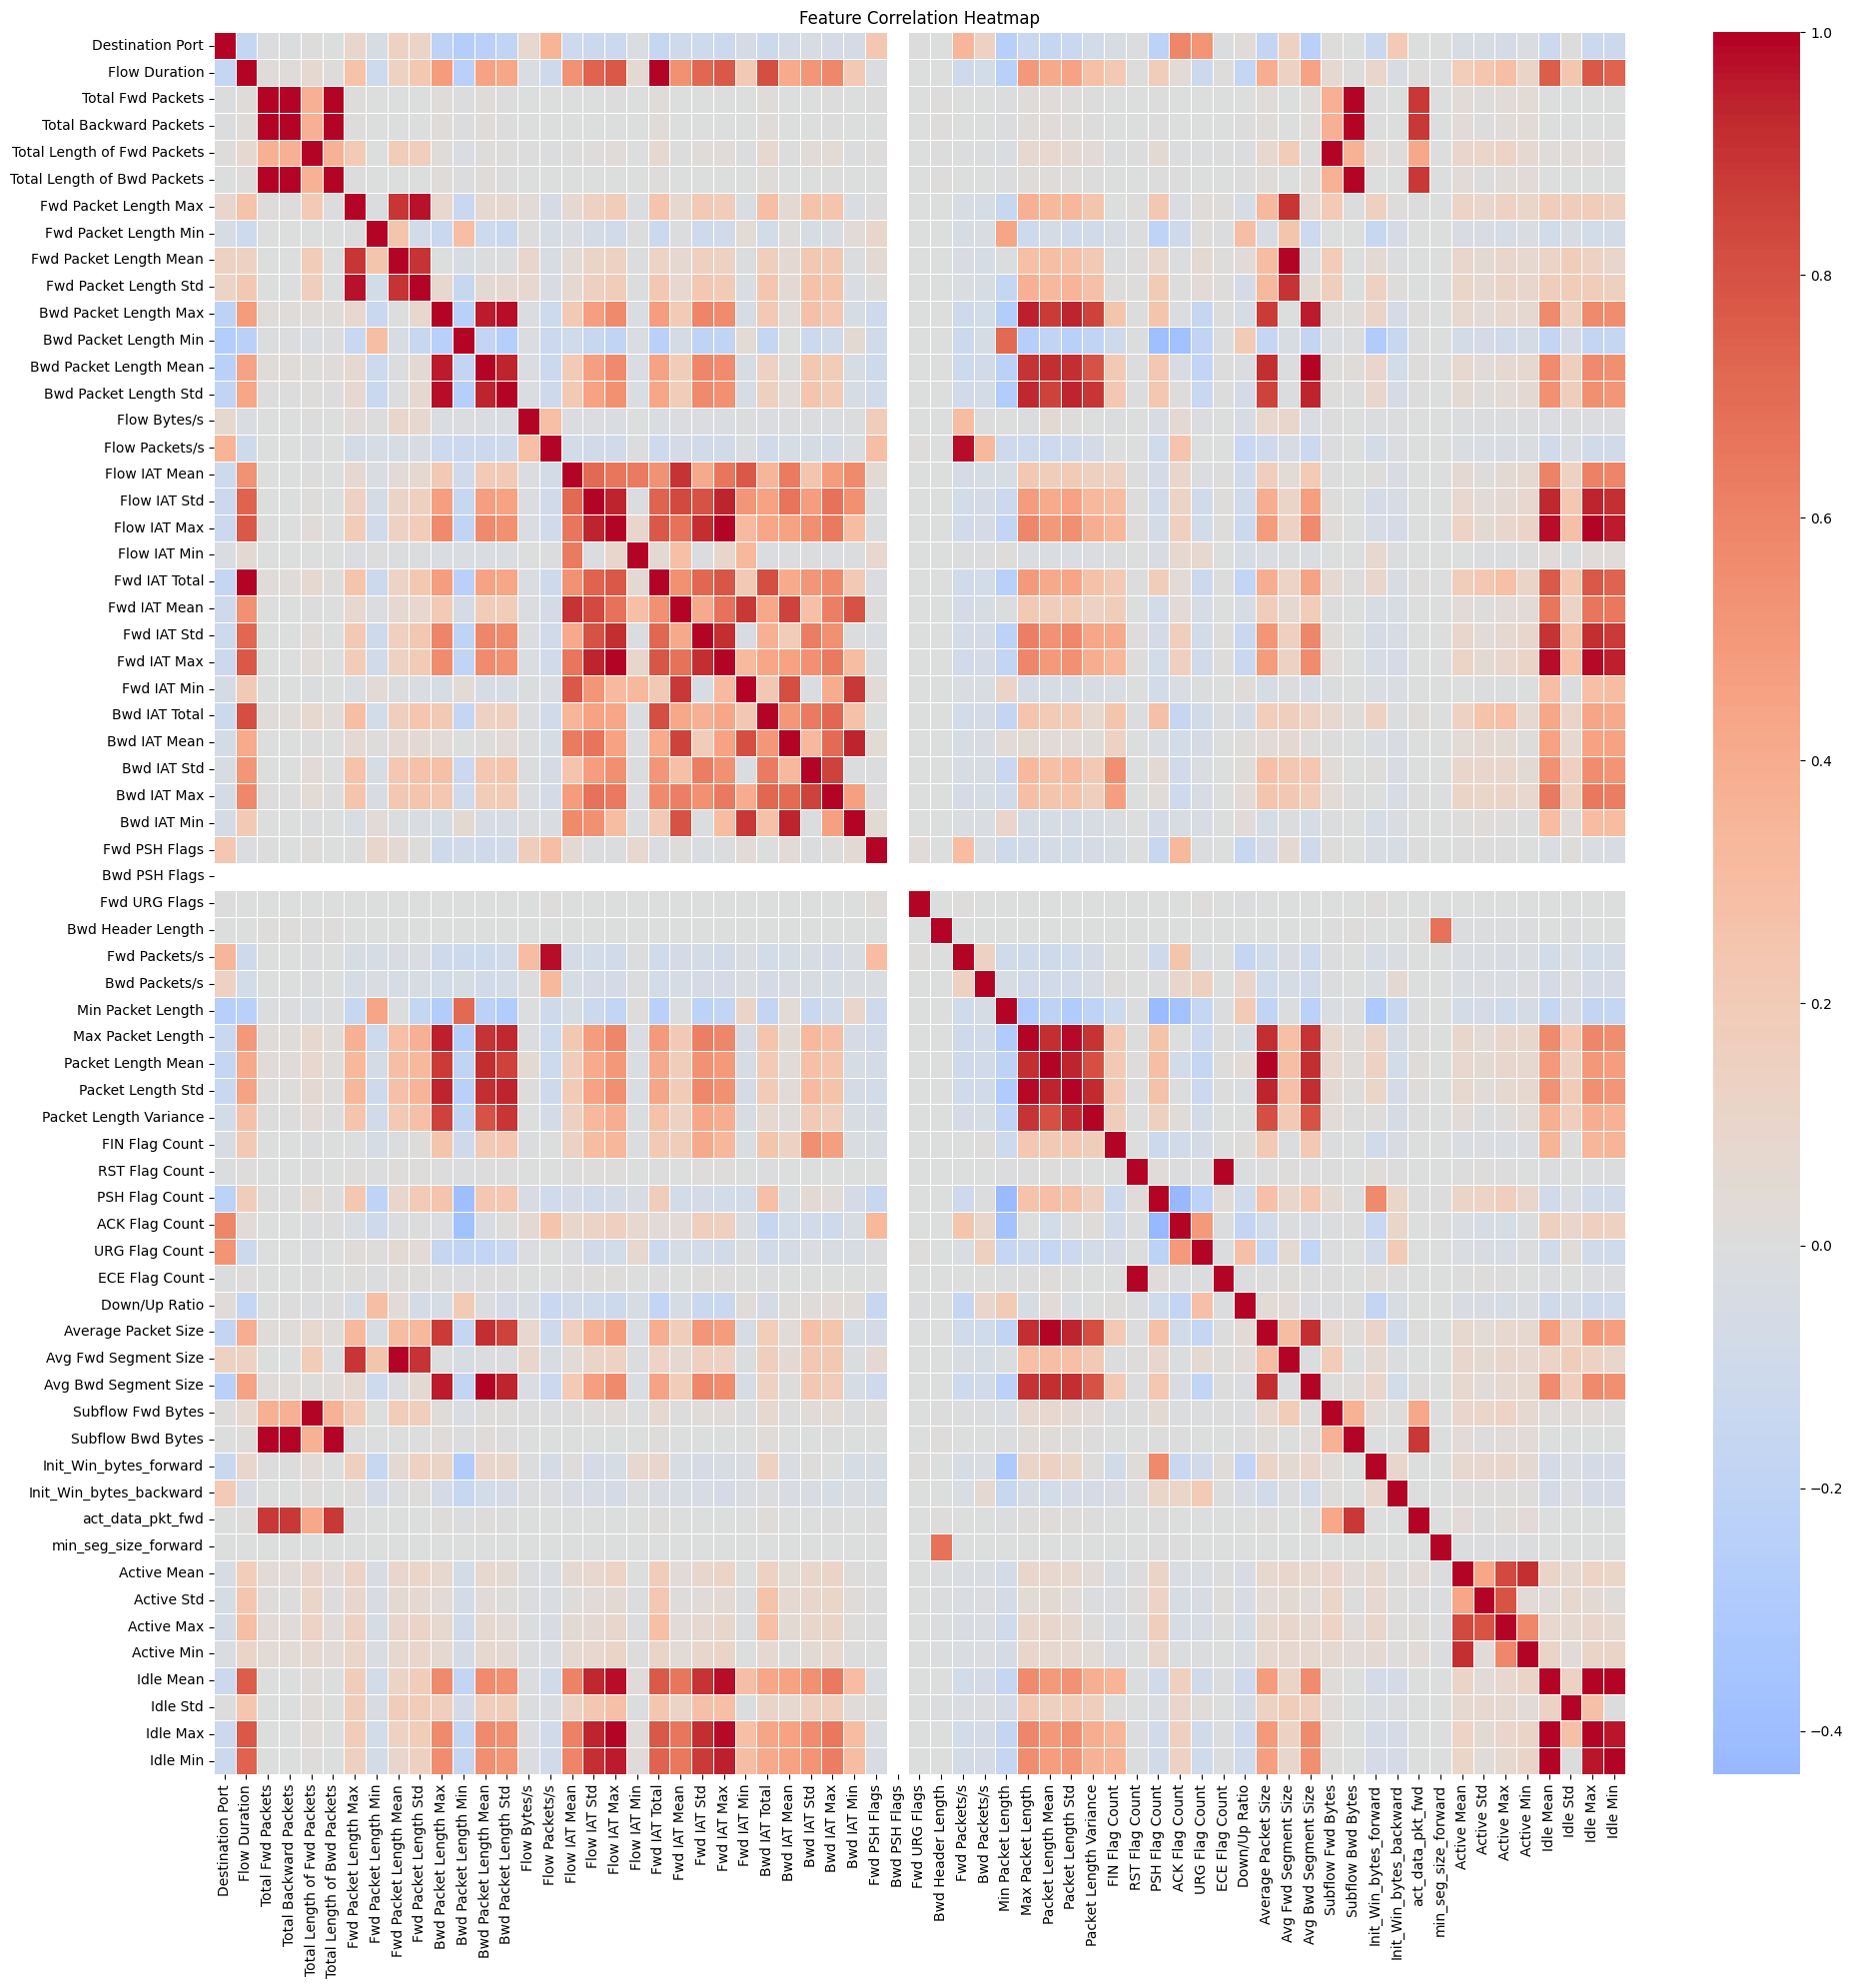

  correlation_analysis: found 75 pair(s) with |r| > 0.85.
  drop_high_multicollinearity: dropping 5 column(s): ['Total Backward Packets', 'Total Length of Bwd Packets', 'Subflow Bwd Bytes', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size']
  drop_low_importance_features: dropping 8 column(s): ['ECE Flag Count', 'RST Flag Count', 'Fwd URG Flags', 'Idle Std', 'Fwd PSH Flags', 'Active Std', 'Down/Up Ratio', 'URG Flag Count']
  get_feature_types: 52 numerical, 0 categorical features.
  ✓ Feature engineering complete.
    Final shape : 2,520,762 rows × 53 columns
    Numerical features remaining: 52

Final shape: (2520762, 53)


,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,...,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min,Attack Type
0,54865,3,2,12,6,6,6.0,0.0,0,0,...,-1,1,20,0.0,0,0,0.0,0,0,BENIGN
1,55054,109,1,6,6,6,6.0,0.0,6,6,...,256,0,20,0.0,0,0,0.0,0,0,BENIGN
2,55055,52,1,6,6,6,6.0,0.0,6,6,...,256,0,20,0.0,0,0,0.0,0,0,BENIGN


In [6]:
df_final = run_feature_engineering_pipeline(
    df_clean,
    corr_threshold=0.85,
    plot_heatmap=True,
)

print(f'Final shape: {df_final.shape}')
df_final.head(3)

## 4. (Optional) EDA — Statistical Analysis

These cells run the Levene and Kruskal-Wallis tests plus an RF-based importance
check.  They are **informational** — the results were already used to determine
which columns to drop above.

Uncomment and run only when you want to reproduce or explore the analysis.

In [ ]:
# from src.eda import (
#     analyze_variance_homogeneity,
#     analyze_feature_importance_kruskal,
#     analyze_feature_importance_rf,
#     plot_feature_importance_combined,
# )
#
# num_feat, _ = get_feature_types(df_final)
#
# # Levene test
# variance_result = analyze_variance_homogeneity(df_final, num_feat)
#
# # Kruskal-Wallis
# h_df = analyze_feature_importance_kruskal(df_final, num_feat)
#
# # Random Forest importance
# importance_df, cm, rf_labels, cv_scores = analyze_feature_importance_rf(df_final, num_feat)
#
# # Combined visualisation
# comp = importance_df.merge(h_df, on='Feature', how='left').sort_values('Importance', ascending=False)
# plot_feature_importance_combined(comp)

## 5. Save Output

In [8]:
OUTPUT_PATH = os.path.join(PROJECT_ROOT, 'cicids2017_cleaned.csv')
df_final.to_csv(OUTPUT_PATH, index=False)
print(f'Saved cleaned dataset → {OUTPUT_PATH}')
print(f'Shape: {df_final.shape[0]:,} rows × {df_final.shape[1]} columns')

Saved cleaned dataset → /Users/anhoang/PycharmProjects/DAP391m/Project/cicids2017_cleaned.csv
Shape: 2,520,762 rows × 53 columns
